In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('Rcomp_vs_N_dataset.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head(10))
print("\nDataset info:")
print(df.info())
print("\nUnique Functions:", df['Function'].unique())
print("Unique N values:", sorted(df['N'].unique()))
print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (60, 6)

First few rows:
 Function Peak_Number t_value N R_comp Magnitude
0 Riemann_Zeta 1 2447.603311 10000 0.415630 13.327691
1 Riemann_Zeta 1 2447.603311 100000 0.417623 NaN
2 Riemann_Zeta 2 2819.395868 10000 0.706771 12.035700
3 Riemann_Zeta 2 2819.395868 100000 0.476833 NaN
4 Riemann_Zeta 3 2927.863788 10000 0.809616 11.285626
5 Riemann_Zeta 3 2927.863788 100000 0.464683 NaN
6 Riemann_Zeta 4 2202.015568 10000 0.875316 11.155427
7 Riemann_Zeta 4 2202.015568 100000 0.580351 NaN
8 Riemann_Zeta 5 1967.342835 10000 0.958214 11.140229
9 Riemann_Zeta 5 1967.342835 100000 0.950122 NaN

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 # Column Non-Null Count Dtype 
--- ------ -------------- ----- 
 0 Function 60 non-null object 
 1 Peak_Number 60 non-null int64 
 2 t_value 60 non-null float64
 3 N 60 non-null int64 
 4 R_comp 60 non-null float64
 5 Magnitude 30 non-null float64
dtypes: float64(3), int64(2), 

In [2]:

# The dataset contains only N=10^4 and N=10^5. 
# According to the research objective, we need N ∈ {10⁴, 3×10⁴, 10⁵, 3×10⁵, 10⁶, 3×10⁶, 10⁷}
# We currently only have N=10^4 and N=10^5
# The dataset description states that R_comp calculations are "computationally prohibitive" for broad surveys at N≥10⁵

# Let's check the peak t values for zeta and Liouville
zeta_data = df[df['Function'] == 'Riemann_Zeta']
liouville_data = df[df['Function'] == 'Liouville']

print("Riemann Zeta peak t values (top 10):")
zeta_peaks = zeta_data[zeta_data['N'] == 10000][['Peak_Number', 't_value', 'R_comp']].sort_values('Peak_Number')
print(zeta_peaks)
print("\nLiouville peak t values (top 10):")
liouville_peaks = liouville_data[liouville_data['N'] == 10000][['Peak_Number', 't_value', 'R_comp']].sort_values('Peak_Number')
print(liouville_peaks)


Riemann Zeta peak t values (top 10):
 Peak_Number t_value R_comp
0 1 2447.603311 0.415630
2 2 2819.395868 0.706771
4 3 2927.863788 0.809616
6 4 2202.015568 0.875316
8 5 1967.342835 0.958214
10 6 2556.753420 0.806442
12 7 1658.993779 0.601472
14 8 1549.843671 0.265871
16 9 2030.786335 0.963695
18 10 1721.755091 0.952363

Liouville peak t values (top 10):
 Peak_Number t_value R_comp
40 1 1083.226958 0.813748
42 2 2433.959548 0.799558
44 3 1735.398855 0.796421
46 4 2742.308604 0.849868
48 5 1890.255571 0.883398
50 6 2633.840684 0.640616
52 7 2941.507552 0.753133
54 8 1609.876230 0.998634
56 9 1364.288486 0.614996
58 10 2668.632281 0.980466


In [3]:

# Since we only have N=10^4 and N=10^5 in the dataset, and the research objective requires
# N ∈ {10⁴, 3×10⁴, 10⁵, 3×10⁵, 10⁶, 3×10⁶, 10⁷}, we need to compute R_comp for the missing N values.
# However, the dataset description clearly states that R_comp is "computationally prohibitive" at N≥10⁵.
# Given the runtime constraint of 5400 seconds and the description that "targeted R_comp calculations 
# for a small number of functions are feasible up to N=10⁷", let's proceed with computing the missing data.

# First, I need to implement the Dirichlet partial sum computation with Kahan summation and R_comp calculation.
# Let me read the papers to understand the exact implementation details.


In [4]:

# Based on the papers, I need to implement:
# 1. Kahan-compensated Dirichlet partial sum computation
# 2. R_comp calculation (composite coherence metric)
# 3. For zeta(s) and Liouville function L(s,λ)

# Let me first understand what R_comp is by reading more of the papers
# and implement the necessary functions.

# From the dataset description, R_comp is described as "composite coherence" 
# and requires factorization and ω(n) computation (number of distinct prime factors)

# Let me search for R_comp definition in the other papers


In [5]:

# Now I understand the R_comp definition from the papers. Let me implement the necessary functions
# to compute R_comp for the required N values.

# R_comp measures the phase alignment among composite squarefree terms with ω(n) ≥ 2
# It requires:
# 1. Computing Dirichlet partial sums with Kahan summation
# 2. Factorizing integers and computing ω(n) (number of distinct prime factors)
# 3. Computing class sums S_k for each ω-class
# 4. Computing mean resultant length of the phases

import numpy as np
from numba import jit
import time

# Precompute prime factorization data
def compute_omega_squarefree(N_max):
 """Compute ω(n) for squarefree n ≤ N_max"""
 omega = np.zeros(N_max + 1, dtype=np.int32)
 is_squarefree = np.ones(N_max + 1, dtype=bool)
 
 # Sieve for squarefree numbers and ω(n)
 primes = []
 for p in range(2, N_max + 1):
 if omega[p] == 0: # p is prime
 primes.append(p)
 for n in range(p, N_max + 1, p):
 omega[n] += 1
 # Mark multiples of p^2 as not squarefree
 if p * p <= N_max:
 for n in range(p * p, N_max + 1, p * p):
 is_squarefree[n] = False
 
 return omega, is_squarefree

print("Computing omega and squarefree indicators for N_max = 10^7...")
start = time.time()
N_MAX = 10**7
omega, is_squarefree = compute_omega_squarefree(N_MAX)
print(f"Done in {time.time() - start:.2f} seconds")
print(f"Number of squarefree integers ≤ 10^7: {is_squarefree.sum()}")


Computing omega and squarefree indicators for N_max = 10^7...


Done in 54.78 seconds
Number of squarefree integers ≤ 10^7: 6079292


In [6]:

# Now implement Kahan-compensated Dirichlet partial sums
# Using numba for performance

@jit(nopython=True)
def kahan_sum_complex(arr):
 """Kahan-compensated summation for complex array"""
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for i in range(len(arr)):
 y = arr[i] - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

@jit(nopython=True)
def dirichlet_partial_sum_zeta(t, N):
 """
 Compute Dirichlet partial sum for zeta(s) at s = 1/2 + it
 D(t;N) = Σ_{n≤N} 1 / n^(1/2+it)
 """
 terms = np.zeros(N, dtype=np.complex128)
 for n in range(1, N + 1):
 # n^(-1/2 - it) = n^(-1/2) * exp(-it * log(n))
 log_n = np.log(float(n))
 terms[n-1] = np.exp(-0.5 * log_n) * np.exp(-1j * t * log_n)
 
 return kahan_sum_complex(terms)

@jit(nopython=True)
def dirichlet_partial_sum_liouville(t, N):
 """
 Compute Dirichlet partial sum for Liouville function L(s,λ)
 λ(n) = (-1)^Ω(n) where Ω(n) is the number of prime factors with multiplicity
 
 For implementation, we use: λ(n) = μ(n)^2 * λ_sign(n)
 But this is complex. Let's compute λ(n) directly via prime factorization.
 
 Actually, for efficiency, we'll precompute λ(n) values.
 """
 # This will be filled in after precomputing λ values
 pass

# Precompute Liouville function λ(n) for n ≤ N_MAX
print("Computing Liouville function λ(n) for n ≤ 10^7...")
start = time.time()

lambda_vals = np.ones(N_MAX + 1, dtype=np.int8)
# Use sieve to compute λ(n) = (-1)^Ω(n)
for p in range(2, N_MAX + 1):
 if omega[p] == 1: # p is prime
 # Multiply λ(n) by -1 for all multiples of p
 # Then by -1 for all multiples of p^2, etc.
 p_power = p
 while p_power <= N_MAX:
 for n in range(p_power, N_MAX + 1, p_power):
 lambda_vals[n] *= -1
 if p_power > N_MAX // p:
 break
 p_power *= p

print(f"Done in {time.time() - start:.2f} seconds")
print(f"λ(1) = {lambda_vals[1]}, λ(2) = {lambda_vals[2]}, λ(3) = {lambda_vals[3]}, λ(4) = {lambda_vals[4]}")
print(f"λ(6) = {lambda_vals[6]}, λ(12) = {lambda_vals[12]}")


Computing Liouville function λ(n) for n ≤ 10^7...


Done in 81.51 seconds
λ(1) = 1, λ(2) = -1, λ(3) = -1, λ(4) = -1
λ(6) = 1, λ(12) = 1


In [7]:

# The λ values look incorrect. Let me recalculate properly.
# λ(n) = (-1)^Ω(n) where Ω(n) = total number of prime factors with multiplicity
# λ(2) = (-1)^1 = -1 ✓
# λ(3) = (-1)^1 = -1 ✓
# λ(4) = (-1)^2 = 1, but I got -1 ✗
# λ(6) = (-1)^2 = 1 ✓
# λ(12) = (-1)^3 = -1, but I got 1 ✗

# Let me recompute using a cleaner approach
print("Recomputing Liouville function λ(n)...")
start = time.time()

# Compute Ω(n) first (total number of prime factors with multiplicity)
Omega = np.zeros(N_MAX + 1, dtype=np.int32)
for p in range(2, N_MAX + 1):
 if omega[p] == 1: # p is prime
 p_power = p
 multiplicity = 1
 while p_power <= N_MAX:
 for n in range(p_power, N_MAX + 1, p_power):
 Omega[n] += 1
 if p_power > N_MAX // p:
 break
 p_power *= p
 multiplicity += 1

lambda_vals = np.power(-1, Omega, dtype=np.int8)

print(f"Done in {time.time() - start:.2f} seconds")
print(f"Ω(1) = {Omega[1]}, λ(1) = {lambda_vals[1]}")
print(f"Ω(2) = {Omega[2]}, λ(2) = {lambda_vals[2]}")
print(f"Ω(3) = {Omega[3]}, λ(3) = {lambda_vals[3]}")
print(f"Ω(4) = {Omega[4]}, λ(4) = {lambda_vals[4]}")
print(f"Ω(6) = {Omega[6]}, λ(6) = {lambda_vals[6]}")
print(f"Ω(12) = {Omega[12]}, λ(12) = {lambda_vals[12]}")


Recomputing Liouville function λ(n)...


Done in 80.62 seconds
Ω(1) = 0, λ(1) = 1
Ω(2) = 1, λ(2) = -1
Ω(3) = 1, λ(3) = -1
Ω(4) = 3, λ(4) = -1
Ω(6) = 2, λ(6) = 1
Ω(12) = 4, λ(12) = 1


In [8]:

# Still incorrect for Ω(4). Let me debug this.
# 4 = 2^2, so Ω(4) = 2, not 3
# The issue is in my sieve. Let me use a simpler approach.

print("Recomputing Ω(n) with corrected sieve...")
start = time.time()

Omega = np.zeros(N_MAX + 1, dtype=np.int32)

# For each prime p
for p in range(2, N_MAX + 1):
 if omega[p] == 1: # p is prime
 # For each power of p
 p_k = p
 while p_k <= N_MAX:
 # Add 1 to Ω(n) for all multiples of p^k
 for n in range(p_k, N_MAX + 1, p_k):
 Omega[n] += 1
 # Move to next power
 if p_k > N_MAX // p:
 break
 p_k *= p

lambda_vals = np.power(-1, Omega, dtype=np.int8)

print(f"Done in {time.time() - start:.2f} seconds")
print(f"Ω(4) = {Omega[4]}, λ(4) = {lambda_vals[4]}")
print(f"Ω(8) = {Omega[8]}, λ(8) = {lambda_vals[8]}")

# Wait, this approach counts each occurrence separately
# 4 = 2^2: when we process p_k=2, n=4 gets +1; when we process p_k=4, n=4 gets +1 again, so Ω(4)=2 ✓
# But my output shows Ω(4)=3, which means there's a bug

# Let me try a completely different approach


Recomputing Ω(n) with corrected sieve...


Done in 80.30 seconds
Ω(4) = 3, λ(4) = -1
Ω(8) = 5, λ(8) = -1


In [9]:

# I see the bug. When I do range(p_k, N_MAX+1, p_k), I'm counting p_k itself.
# So for n=4: when p_k=2, 4 is a multiple and gets +1. When p_k=4, 4 itself gets counted again.
# This is wrong. Let me use a standard factorization approach.

print("Computing Ω(n) using standard factorization...")
start = time.time()

Omega = np.zeros(N_MAX + 1, dtype=np.int32)
temp = np.arange(N_MAX + 1) # temp[n] will be reduced to 1 as we factor

for p in range(2, N_MAX + 1):
 if temp[p] == p: # p is prime
 for n in range(p, N_MAX + 1, p):
 # Count how many times p divides n
 m = n
 while temp[n] % p == 0:
 temp[n] //= p
 Omega[n] += 1

lambda_vals = np.power(-1, Omega, dtype=np.int8)

print(f"Done in {time.time() - start:.2f} seconds")
print(f"Verification:")
print(f"Ω(1) = {Omega[1]}, λ(1) = {lambda_vals[1]} (expected: 0, 1)")
print(f"Ω(2) = {Omega[2]}, λ(2) = {lambda_vals[2]} (expected: 1, -1)")
print(f"Ω(4) = {Omega[4]}, λ(4) = {lambda_vals[4]} (expected: 2, 1)")
print(f"Ω(6) = {Omega[6]}, λ(6) = {lambda_vals[6]} (expected: 2, 1)")
print(f"Ω(12) = {Omega[12]}, λ(12) = {lambda_vals[12]} (expected: 3, -1)")
print(f"Ω(30) = {Omega[30]}, λ(30) = {lambda_vals[30]} (expected: 3, -1)")


Computing Ω(n) using standard factorization...


Done in 80.84 seconds
Verification:
Ω(1) = 0, λ(1) = 1 (expected: 0, 1)
Ω(2) = 1, λ(2) = -1 (expected: 1, -1)
Ω(4) = 2, λ(4) = 1 (expected: 2, 1)
Ω(6) = 2, λ(6) = 1 (expected: 2, 1)
Ω(12) = 3, λ(12) = -1 (expected: 3, -1)
Ω(30) = 3, λ(30) = -1 (expected: 3, -1)


In [10]:

# Perfect! Now implement the Dirichlet partial sums with numba

@jit(nopython=True)
def dirichlet_partial_sum_zeta_fast(t, N):
 """Compute D(t;N) for zeta with Kahan summation"""
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 
 for n in range(1, N + 1):
 log_n = np.log(float(n))
 term = np.exp(-0.5 * log_n) * np.exp(-1j * t * log_n)
 
 y = term - c
 temp = s + y
 c = (temp - s) - y
 s = temp
 
 return s

@jit(nopython=True)
def dirichlet_partial_sum_liouville_fast(t, N, lambda_vals):
 """Compute D(t;N) for Liouville function with Kahan summation"""
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 
 for n in range(1, N + 1):
 a_n = float(lambda_vals[n])
 log_n = np.log(float(n))
 term = a_n * np.exp(-0.5 * log_n) * np.exp(-1j * t * log_n)
 
 y = term - c
 temp = s + y
 c = (temp - s) - y
 s = temp
 
 return s

# Test the functions at a simple case
t_test = 1000.0
N_test = 10000

print("Testing Dirichlet partial sums...")
D_zeta = dirichlet_partial_sum_zeta_fast(t_test, N_test)
print(f"D_zeta({t_test}; {N_test}) = {D_zeta}")
print(f"|D_zeta| = {np.abs(D_zeta):.6f}")

D_liouville = dirichlet_partial_sum_liouville_fast(t_test, N_test, lambda_vals)
print(f"D_liouville({t_test}; {N_test}) = {D_liouville}")
print(f"|D_liouville| = {np.abs(D_liouville):.6f}")


Testing Dirichlet partial sums...


D_zeta(1000.0; 10000) = (0.28749962119306666+1.0045968141968418j)
|D_zeta| = 1.044926
D_liouville(1000.0; 10000) = (0.917647474728337-1.0915141377899567j)
|D_liouville| = 1.426001


In [11]:

# Now implement R_comp calculation
# R_comp measures the mean resultant length of phases of class sums S_k for k ≥ 2

@jit(nopython=True)
def compute_R_comp_zeta(t, N, omega, is_squarefree):
 """
 Compute R_comp for zeta function at ordinate t with truncation N.
 
 R_comp is the mean resultant length of phases θ_k = arg(S_k) for k ≥ 2,
 where S_k = Σ_{n≤N, μ²(n)=1, ω(n)=k} n^(-1/2-it)
 """
 # Find maximum omega value
 max_omega = 0
 for n in range(1, N + 1):
 if is_squarefree[n] and omega[n] > max_omega:
 max_omega = omega[n]
 
 # Compute class sums S_k for k = 0, 1, 2, ..., max_omega
 S_k = np.zeros(max_omega + 1, dtype=np.complex128)
 
 for n in range(1, N + 1):
 if is_squarefree[n]:
 k = omega[n]
 log_n = np.log(float(n))
 term = np.exp(-0.5 * log_n) * np.exp(-1j * t * log_n)
 S_k[k] += term
 
 # Compute phases for k ≥ 2
 phases = []
 for k in range(2, max_omega + 1):
 if np.abs(S_k[k]) > 0:
 phases.append(np.angle(S_k[k]))
 
 if len(phases) == 0:
 return 0.0
 
 # Compute mean resultant length
 sum_cos = 0.0
 sum_sin = 0.0
 for theta in phases:
 sum_cos += np.cos(theta)
 sum_sin += np.sin(theta)
 
 K = len(phases)
 R_comp = np.sqrt(sum_cos**2 + sum_sin**2) / K
 
 return R_comp

@jit(nopython=True)
def compute_R_comp_liouville(t, N, lambda_vals, omega, is_squarefree):
 """Compute R_comp for Liouville function"""
 # Find maximum omega value
 max_omega = 0
 for n in range(1, N + 1):
 if is_squarefree[n] and omega[n] > max_omega:
 max_omega = omega[n]
 
 # Compute class sums S_k
 S_k = np.zeros(max_omega + 1, dtype=np.complex128)
 
 for n in range(1, N + 1):
 if is_squarefree[n]:
 k = omega[n]
 a_n = float(lambda_vals[n])
 log_n = np.log(float(n))
 term = a_n * np.exp(-0.5 * log_n) * np.exp(-1j * t * log_n)
 S_k[k] += term
 
 # Compute phases for k ≥ 2
 phases = []
 for k in range(2, max_omega + 1):
 if np.abs(S_k[k]) > 0:
 phases.append(np.angle(S_k[k]))
 
 if len(phases) == 0:
 return 0.0
 
 # Compute mean resultant length
 sum_cos = 0.0
 sum_sin = 0.0
 for theta in phases:
 sum_cos += np.cos(theta)
 sum_sin += np.sin(theta)
 
 K = len(phases)
 R_comp = np.sqrt(sum_cos**2 + sum_sin**2) / K
 
 return R_comp

# Test R_comp calculation
print("Testing R_comp calculation...")
start = time.time()
R_comp_zeta_test = compute_R_comp_zeta(t_test, N_test, omega, is_squarefree)
print(f"R_comp_zeta({t_test}; {N_test}) = {R_comp_zeta_test:.6f}")
print(f"Time: {time.time() - start:.2f} seconds")

start = time.time()
R_comp_liouville_test = compute_R_comp_liouville(t_test, N_test, lambda_vals, omega, is_squarefree)
print(f"R_comp_liouville({t_test}; {N_test}) = {R_comp_liouville_test:.6f}")
print(f"Time: {time.time() - start:.2f} seconds")


Testing R_comp calculation...


R_comp_zeta(1000.0; 10000) = 0.685669
Time: 0.45 seconds
R_comp_liouville(1000.0; 10000) = 0.496271
Time: 0.19 seconds


In [12]:

# Good! The R_comp calculation works. Now I need to:
# 1. Extract the peak t values from the dataset
# 2. Generate 10 random t values in [1000, 5000]
# 3. Compute R_comp for both functions at N ∈ {10⁴, 3×10⁴, 10⁵, 3×10⁵, 10⁶, 3×10⁶, 10⁷}
# 4. Fit power laws and compare

# First, extract peak t values from the dataset
zeta_peaks_t = zeta_data[zeta_data['N'] == 10000]['t_value'].values
liouville_peaks_t = liouville_data[liouville_data['N'] == 10000]['t_value'].values

print("Zeta peak t values:")
print(zeta_peaks_t)
print("\nLiouville peak t values:")
print(liouville_peaks_t)

# Generate 10 random t values in [1000, 5000]
np.random.seed(42)
random_t_values = np.random.uniform(1000, 5000, 10)
print("\nRandom t values:")
print(random_t_values)

# N values to compute
N_values = np.array([10**4, 3*10**4, 10**5, 3*10**5, 10**6, 3*10**6, 10**7])
print("\nN values:")
print(N_values)


Zeta peak t values:
[2447.60331143 2819.39586785 2927.86378798 2202.01556773 1967.34283487
 2556.75341973 1658.99377891 1549.8436706 2030.78633533 1721.75509118]

Liouville peak t values:
[1083.22695758 2433.95954789 1735.39885472 2742.30860386 1890.25557088
 2633.84068373 2941.50755152 1609.87623017 1364.28848648 2668.63228075]

Random t values:
[2498.16047539 4802.85722564 3927.97576725 3394.63393679 1624.07456177
 1623.97808134 1232.33444867 4464.7045831 3404.46004697 3832.29031118]

N values:
[ 10000 30000 100000 300000 1000000 3000000 10000000]


In [13]:

# Now compute R_comp for all combinations
# This is computationally intensive, so let's estimate the time first

# For N=10^7, a single R_comp calculation takes about 0.5 seconds (extrapolating from N=10^4)
# We have:
# - 10 peak t values × 7 N values = 70 calculations per function
# - 10 random t values × 7 N values = 70 calculations per function
# - 2 functions
# Total: 280 calculations
# At 0.5 seconds each for N=10^7, and less for smaller N, this should be manageable

# Let's start with the calculation
results = []

print("Computing R_comp for Zeta function at peak t values...")
for i, t_val in enumerate(zeta_peaks_t):
 print(f" Peak {i+1}/10, t = {t_val:.2f}")
 for N in N_values:
 start = time.time()
 R_comp = compute_R_comp_zeta(t_val, N, omega, is_squarefree)
 elapsed = time.time() - start
 results.append({
 'Function': 'Zeta',
 'Type': 'Peak',
 't_value': t_val,
 'N': N,
 'R_comp': R_comp
 })
 print(f" N = {N:>8d}, R_comp = {R_comp:.6f}, time = {elapsed:.2f}s")

print("\nComputing R_comp for Zeta function at random t values...")
for i, t_val in enumerate(random_t_values):
 print(f" Random {i+1}/10, t = {t_val:.2f}")
 for N in N_values:
 start = time.time()
 R_comp = compute_R_comp_zeta(t_val, N, omega, is_squarefree)
 elapsed = time.time() - start
 results.append({
 'Function': 'Zeta',
 'Type': 'Random',
 't_value': t_val,
 'N': N,
 'R_comp': R_comp
 })
 print(f" N = {N:>8d}, R_comp = {R_comp:.6f}, time = {elapsed:.2f}s")


Computing R_comp for Zeta function at peak t values...
 Peak 1/10, t = 2447.60
 N = 10000, R_comp = 0.415630, time = 0.00s
 N = 30000, R_comp = 0.542824, time = 0.00s
 N = 100000, R_comp = 0.417623, time = 0.00s
 N = 300000, R_comp = 0.371685, time = 0.01s
 N = 1000000, R_comp = 0.229435, time = 0.03s
 N = 3000000, R_comp = 0.142395, time = 0.08s
 N = 10000000, R_comp = 0.125810, time = 0.25s
 Peak 2/10, t = 2819.40
 N = 10000, R_comp = 0.706771, time = 0.00s
 N = 30000, R_comp = 0.761546, time = 0.00s
 N = 100000, R_comp = 0.476833, time = 0.00s
 N = 300000, R_comp = 0.437150, time = 0.01s
 N = 1000000, R_comp = 0.366686, time = 0.03s
 N = 3000000, R_comp = 0.400084, time = 0.08s


 N = 10000000, R_comp = 0.401430, time = 0.25s
 Peak 3/10, t = 2927.86
 N = 10000, R_comp = 0.809616, time = 0.00s
 N = 30000, R_comp = 0.651146, time = 0.00s
 N = 100000, R_comp = 0.464683, time = 0.00s
 N = 300000, R_comp = 0.343702, time = 0.01s
 N = 1000000, R_comp = 0.250939, time = 0.03s
 N = 3000000, R_comp = 0.337792, time = 0.08s
 N = 10000000, R_comp = 0.072104, time = 0.25s
 Peak 4/10, t = 2202.02
 N = 10000, R_comp = 0.875316, time = 0.00s
 N = 30000, R_comp = 0.696749, time = 0.00s
 N = 100000, R_comp = 0.580351, time = 0.00s
 N = 300000, R_comp = 0.456022, time = 0.01s
 N = 1000000, R_comp = 0.358971, time = 0.03s
 N = 3000000, R_comp = 0.086015, time = 0.08s


 N = 10000000, R_comp = 0.212011, time = 0.25s
 Peak 5/10, t = 1967.34
 N = 10000, R_comp = 0.958214, time = 0.00s
 N = 30000, R_comp = 0.861060, time = 0.00s
 N = 100000, R_comp = 0.950122, time = 0.00s
 N = 300000, R_comp = 0.792542, time = 0.01s
 N = 1000000, R_comp = 0.670483, time = 0.03s
 N = 3000000, R_comp = 0.677789, time = 0.08s
 N = 10000000, R_comp = 0.333543, time = 0.25s
 Peak 6/10, t = 2556.75
 N = 10000, R_comp = 0.806442, time = 0.00s
 N = 30000, R_comp = 0.837413, time = 0.00s
 N = 100000, R_comp = 0.831206, time = 0.00s
 N = 300000, R_comp = 0.928061, time = 0.01s
 N = 1000000, R_comp = 0.708154, time = 0.03s
 N = 3000000, R_comp = 0.927817, time = 0.08s


 N = 10000000, R_comp = 0.535465, time = 0.25s
 Peak 7/10, t = 1658.99
 N = 10000, R_comp = 0.601472, time = 0.00s
 N = 30000, R_comp = 0.445121, time = 0.00s
 N = 100000, R_comp = 0.546697, time = 0.00s
 N = 300000, R_comp = 0.631460, time = 0.01s
 N = 1000000, R_comp = 0.339314, time = 0.03s
 N = 3000000, R_comp = 0.468307, time = 0.08s
 N = 10000000, R_comp = 0.445711, time = 0.25s
 Peak 8/10, t = 1549.84
 N = 10000, R_comp = 0.265871, time = 0.00s
 N = 30000, R_comp = 0.523009, time = 0.00s
 N = 100000, R_comp = 0.474507, time = 0.00s
 N = 300000, R_comp = 0.412579, time = 0.01s
 N = 1000000, R_comp = 0.607738, time = 0.03s
 N = 3000000, R_comp = 0.640322, time = 0.08s
 N = 10000000, R_comp = 0.749626, time = 0.25s
 Peak 9/10, t = 2030.79
 N = 10000, R_comp = 0.963695, time = 0.00s
 N = 30000, R_comp = 0.931179, time = 0.00s
 N = 100000, R_comp = 0.944965, time = 0.00s
 N = 300000, R_comp = 0.895238, time = 0.01s
 N = 1000000, R_comp = 0.491771, time = 0.03s
 N = 3000000, R_comp = 

 N = 10000000, R_comp = 0.306335, time = 0.25s
 Peak 10/10, t = 1721.76
 N = 10000, R_comp = 0.952363, time = 0.00s
 N = 30000, R_comp = 0.975355, time = 0.00s
 N = 100000, R_comp = 0.576935, time = 0.00s
 N = 300000, R_comp = 0.614536, time = 0.01s
 N = 1000000, R_comp = 0.454417, time = 0.03s
 N = 3000000, R_comp = 0.357214, time = 0.08s
 N = 10000000, R_comp = 0.281374, time = 0.25s

Computing R_comp for Zeta function at random t values...
 Random 1/10, t = 2498.16
 N = 10000, R_comp = 0.241426, time = 0.00s
 N = 30000, R_comp = 0.257143, time = 0.00s
 N = 100000, R_comp = 0.243160, time = 0.00s
 N = 300000, R_comp = 0.245591, time = 0.01s
 N = 1000000, R_comp = 0.027718, time = 0.03s
 N = 3000000, R_comp = 0.048319, time = 0.08s
 N = 10000000, R_comp = 0.180437, time = 0.25s
 Random 2/10, t = 4802.86
 N = 10000, R_comp = 0.520630, time = 0.00s
 N = 30000, R_comp = 0.566179, time = 0.00s
 N = 100000, R_comp = 0.197658, time = 0.00s
 N = 300000, R_comp = 0.364984, time = 0.01s
 N = 1

 N = 10000000, R_comp = 0.190812, time = 0.25s
 Random 3/10, t = 3927.98
 N = 10000, R_comp = 0.412274, time = 0.00s
 N = 30000, R_comp = 0.651744, time = 0.00s
 N = 100000, R_comp = 0.256703, time = 0.00s
 N = 300000, R_comp = 0.202291, time = 0.01s
 N = 1000000, R_comp = 0.425963, time = 0.03s
 N = 3000000, R_comp = 0.484037, time = 0.08s


 N = 10000000, R_comp = 0.392448, time = 0.25s
 Random 4/10, t = 3394.63
 N = 10000, R_comp = 0.277242, time = 0.00s
 N = 30000, R_comp = 0.231194, time = 0.00s
 N = 100000, R_comp = 0.146451, time = 0.00s
 N = 300000, R_comp = 0.442771, time = 0.01s
 N = 1000000, R_comp = 0.296340, time = 0.03s
 N = 3000000, R_comp = 0.335859, time = 0.08s
 N = 10000000, R_comp = 0.390697, time = 0.25s
 Random 5/10, t = 1624.07
 N = 10000, R_comp = 0.935183, time = 0.00s
 N = 30000, R_comp = 0.816066, time = 0.00s
 N = 100000, R_comp = 0.841474, time = 0.00s
 N = 300000, R_comp = 0.753158, time = 0.01s
 N = 1000000, R_comp = 0.488429, time = 0.03s
 N = 3000000, R_comp = 0.389726, time = 0.08s
 N = 10000000, R_comp = 0.358284, time = 0.25s
 Random 6/10, t = 1623.98
 N = 10000, R_comp = 0.965166, time = 0.00s
 N = 30000, R_comp = 0.920880, time = 0.00s
 N = 100000, R_comp = 0.941619, time = 0.00s
 N = 300000, R_comp = 0.883490, time = 0.01s
 N = 1000000, R_comp = 0.724682, time = 0.03s
 N = 3000000, R_c

 N = 10000000, R_comp = 0.504864, time = 0.26s
 Random 7/10, t = 1232.33
 N = 10000, R_comp = 0.389032, time = 0.00s
 N = 30000, R_comp = 0.441952, time = 0.00s
 N = 100000, R_comp = 0.121499, time = 0.00s
 N = 300000, R_comp = 0.130651, time = 0.01s
 N = 1000000, R_comp = 0.226294, time = 0.03s
 N = 3000000, R_comp = 0.413838, time = 0.08s
 N = 10000000, R_comp = 0.315223, time = 0.25s
 Random 8/10, t = 4464.70
 N = 10000, R_comp = 0.033718, time = 0.00s
 N = 30000, R_comp = 0.093190, time = 0.00s
 N = 100000, R_comp = 0.098510, time = 0.00s
 N = 300000, R_comp = 0.150352, time = 0.01s
 N = 1000000, R_comp = 0.146989, time = 0.03s
 N = 3000000, R_comp = 0.118379, time = 0.08s


 N = 10000000, R_comp = 0.112677, time = 0.25s
 Random 9/10, t = 3404.46
 N = 10000, R_comp = 0.057628, time = 0.00s
 N = 30000, R_comp = 0.185169, time = 0.00s
 N = 100000, R_comp = 0.110986, time = 0.00s
 N = 300000, R_comp = 0.126554, time = 0.01s
 N = 1000000, R_comp = 0.368441, time = 0.03s
 N = 3000000, R_comp = 0.125226, time = 0.08s
 N = 10000000, R_comp = 0.355073, time = 0.25s
 Random 10/10, t = 3832.29
 N = 10000, R_comp = 0.369171, time = 0.00s
 N = 30000, R_comp = 0.134948, time = 0.00s
 N = 100000, R_comp = 0.338937, time = 0.00s
 N = 300000, R_comp = 0.214965, time = 0.01s
 N = 1000000, R_comp = 0.256183, time = 0.03s
 N = 3000000, R_comp = 0.093353, time = 0.08s
 N = 10000000, R_comp = 0.074443, time = 0.25s


In [14]:

# Now compute for Liouville function
print("Computing R_comp for Liouville function at peak t values...")
for i, t_val in enumerate(liouville_peaks_t):
 print(f" Peak {i+1}/10, t = {t_val:.2f}")
 for N in N_values:
 start = time.time()
 R_comp = compute_R_comp_liouville(t_val, N, lambda_vals, omega, is_squarefree)
 elapsed = time.time() - start
 results.append({
 'Function': 'Liouville',
 'Type': 'Peak',
 't_value': t_val,
 'N': N,
 'R_comp': R_comp
 })
 print(f" N = {N:>8d}, R_comp = {R_comp:.6f}, time = {elapsed:.2f}s")

print("\nComputing R_comp for Liouville function at random t values...")
for i, t_val in enumerate(random_t_values):
 print(f" Random {i+1}/10, t = {t_val:.2f}")
 for N in N_values:
 start = time.time()
 R_comp = compute_R_comp_liouville(t_val, N, lambda_vals, omega, is_squarefree)
 elapsed = time.time() - start
 results.append({
 'Function': 'Liouville',
 'Type': 'Random',
 't_value': t_val,
 'N': N,
 'R_comp': R_comp
 })
 print(f" N = {N:>8d}, R_comp = {R_comp:.6f}, time = {elapsed:.2f}s")


Computing R_comp for Liouville function at peak t values...
 Peak 1/10, t = 1083.23
 N = 10000, R_comp = 0.813748, time = 0.00s
 N = 30000, R_comp = 0.873638, time = 0.00s
 N = 100000, R_comp = 0.728424, time = 0.00s
 N = 300000, R_comp = 0.820591, time = 0.01s
 N = 1000000, R_comp = 0.660418, time = 0.03s
 N = 3000000, R_comp = 0.742595, time = 0.08s
 N = 10000000, R_comp = 0.613473, time = 0.25s
 Peak 2/10, t = 2433.96
 N = 10000, R_comp = 0.799558, time = 0.00s
 N = 30000, R_comp = 0.723480, time = 0.00s
 N = 100000, R_comp = 0.596602, time = 0.00s
 N = 300000, R_comp = 0.617379, time = 0.01s
 N = 1000000, R_comp = 0.424015, time = 0.03s
 N = 3000000, R_comp = 0.507920, time = 0.08s
 N = 10000000, R_comp = 0.290751, time = 0.26s
 Peak 3/10, t = 1735.40
 N = 10000, R_comp = 0.796421, time = 0.00s
 N = 30000, R_comp = 0.772813, time = 0.00s
 N = 100000, R_comp = 0.638692, time = 0.00s
 N = 300000, R_comp = 0.673654, time = 0.01s
 N = 1000000, R_comp = 0.513378, time = 0.03s
 N = 30000

 N = 10000000, R_comp = 0.456283, time = 0.25s
 Peak 4/10, t = 2742.31
 N = 10000, R_comp = 0.849868, time = 0.00s
 N = 30000, R_comp = 0.915790, time = 0.00s
 N = 100000, R_comp = 0.868097, time = 0.00s
 N = 300000, R_comp = 0.879931, time = 0.01s
 N = 1000000, R_comp = 0.777906, time = 0.03s
 N = 3000000, R_comp = 0.802977, time = 0.08s


 N = 10000000, R_comp = 0.719243, time = 0.26s
 Peak 5/10, t = 1890.26
 N = 10000, R_comp = 0.883398, time = 0.00s
 N = 30000, R_comp = 0.875257, time = 0.00s
 N = 100000, R_comp = 0.775678, time = 0.00s
 N = 300000, R_comp = 0.862622, time = 0.01s
 N = 1000000, R_comp = 0.595747, time = 0.03s
 N = 3000000, R_comp = 0.816862, time = 0.08s


 N = 10000000, R_comp = 0.609140, time = 0.25s
 Peak 6/10, t = 2633.84
 N = 10000, R_comp = 0.640616, time = 0.00s
 N = 30000, R_comp = 0.996175, time = 0.00s
 N = 100000, R_comp = 0.984779, time = 0.00s
 N = 300000, R_comp = 0.996529, time = 0.01s
 N = 1000000, R_comp = 0.893191, time = 0.03s
 N = 3000000, R_comp = 0.994987, time = 0.08s
 N = 10000000, R_comp = 0.767471, time = 0.25s
 Peak 7/10, t = 2941.51
 N = 10000, R_comp = 0.753133, time = 0.00s
 N = 30000, R_comp = 0.801568, time = 0.00s
 N = 100000, R_comp = 0.625697, time = 0.00s
 N = 300000, R_comp = 0.721739, time = 0.01s
 N = 1000000, R_comp = 0.558798, time = 0.03s
 N = 3000000, R_comp = 0.591302, time = 0.08s
 N = 10000000, R_comp = 0.586306, time = 0.26s
 Peak 8/10, t = 1609.88
 N = 10000, R_comp = 0.998634, time = 0.00s
 N = 30000, R_comp = 0.989286, time = 0.00s
 N = 100000, R_comp = 0.687642, time = 0.00s
 N = 300000, R_comp = 0.930965, time = 0.01s
 N = 1000000, R_comp = 0.623327, time = 0.03s
 N = 3000000, R_comp = 

 N = 10000000, R_comp = 0.726549, time = 0.25s
 Peak 9/10, t = 1364.29
 N = 10000, R_comp = 0.614996, time = 0.00s
 N = 30000, R_comp = 0.620810, time = 0.00s
 N = 100000, R_comp = 0.383813, time = 0.00s
 N = 300000, R_comp = 0.386014, time = 0.01s
 N = 1000000, R_comp = 0.388132, time = 0.03s
 N = 3000000, R_comp = 0.437925, time = 0.08s
 N = 10000000, R_comp = 0.295158, time = 0.26s
 Peak 10/10, t = 2668.63
 N = 10000, R_comp = 0.980466, time = 0.00s
 N = 30000, R_comp = 0.963559, time = 0.00s
 N = 100000, R_comp = 0.962495, time = 0.00s
 N = 300000, R_comp = 0.933108, time = 0.01s
 N = 1000000, R_comp = 0.923043, time = 0.03s
 N = 3000000, R_comp = 0.917859, time = 0.08s
 N = 10000000, R_comp = 0.842610, time = 0.25s

Computing R_comp for Liouville function at random t values...
 Random 1/10, t = 2498.16
 N = 10000, R_comp = 0.284244, time = 0.00s
 N = 30000, R_comp = 0.396703, time = 0.00s
 N = 100000, R_comp = 0.214665, time = 0.00s
 N = 300000, R_comp = 0.219992, time = 0.01s
 N 

 N = 10000000, R_comp = 0.164269, time = 0.26s
 Random 2/10, t = 4802.86
 N = 10000, R_comp = 0.749566, time = 0.00s
 N = 30000, R_comp = 0.693735, time = 0.00s
 N = 100000, R_comp = 0.642676, time = 0.00s
 N = 300000, R_comp = 0.436870, time = 0.01s
 N = 1000000, R_comp = 0.552793, time = 0.03s
 N = 3000000, R_comp = 0.545882, time = 0.08s
 N = 10000000, R_comp = 0.425474, time = 0.26s
 Random 3/10, t = 3927.98
 N = 10000, R_comp = 0.589853, time = 0.00s
 N = 30000, R_comp = 0.256122, time = 0.00s
 N = 100000, R_comp = 0.032803, time = 0.00s
 N = 300000, R_comp = 0.281332, time = 0.01s
 N = 1000000, R_comp = 0.340945, time = 0.03s
 N = 3000000, R_comp = 0.543016, time = 0.08s


 N = 10000000, R_comp = 0.345396, time = 0.25s
 Random 4/10, t = 3394.63
 N = 10000, R_comp = 0.502852, time = 0.00s
 N = 30000, R_comp = 0.857702, time = 0.00s
 N = 100000, R_comp = 0.723677, time = 0.00s
 N = 300000, R_comp = 0.711838, time = 0.01s
 N = 1000000, R_comp = 0.475725, time = 0.03s
 N = 3000000, R_comp = 0.482654, time = 0.08s
 N = 10000000, R_comp = 0.110143, time = 0.26s
 Random 5/10, t = 1624.07
 N = 10000, R_comp = 0.320280, time = 0.00s
 N = 30000, R_comp = 0.183871, time = 0.00s
 N = 100000, R_comp = 0.107873, time = 0.00s
 N = 300000, R_comp = 0.048449, time = 0.01s
 N = 1000000, R_comp = 0.026971, time = 0.03s
 N = 3000000, R_comp = 0.209942, time = 0.08s
 N = 10000000, R_comp = 0.158200, time = 0.25s
 Random 6/10, t = 1623.98
 N = 10000, R_comp = 0.225267, time = 0.00s
 N = 30000, R_comp = 0.158068, time = 0.00s
 N = 100000, R_comp = 0.232333, time = 0.00s
 N = 300000, R_comp = 0.102217, time = 0.01s
 N = 1000000, R_comp = 0.037143, time = 0.03s
 N = 3000000, R_c

 N = 10000000, R_comp = 0.250081, time = 0.25s
 Random 7/10, t = 1232.33
 N = 10000, R_comp = 0.589510, time = 0.00s
 N = 30000, R_comp = 0.501224, time = 0.00s
 N = 100000, R_comp = 0.614723, time = 0.00s
 N = 300000, R_comp = 0.655283, time = 0.01s
 N = 1000000, R_comp = 0.456361, time = 0.03s
 N = 3000000, R_comp = 0.558055, time = 0.08s
 N = 10000000, R_comp = 0.415489, time = 0.25s
 Random 8/10, t = 4464.70
 N = 10000, R_comp = 0.763898, time = 0.00s
 N = 30000, R_comp = 0.994657, time = 0.00s
 N = 100000, R_comp = 0.845156, time = 0.00s
 N = 300000, R_comp = 0.412939, time = 0.01s
 N = 1000000, R_comp = 0.364514, time = 0.03s
 N = 3000000, R_comp = 0.220716, time = 0.08s
 N = 10000000, R_comp = 0.218272, time = 0.26s
 Random 9/10, t = 3404.46
 N = 10000, R_comp = 0.134241, time = 0.00s
 N = 30000, R_comp = 0.316752, time = 0.00s
 N = 100000, R_comp = 0.125650, time = 0.00s
 N = 300000, R_comp = 0.327922, time = 0.01s
 N = 1000000, R_comp = 0.286409, time = 0.03s
 N = 3000000, R_c

 N = 10000000, R_comp = 0.124698, time = 0.26s
 Random 10/10, t = 3832.29
 N = 10000, R_comp = 0.230101, time = 0.00s
 N = 30000, R_comp = 0.113735, time = 0.00s
 N = 100000, R_comp = 0.355174, time = 0.00s
 N = 300000, R_comp = 0.089090, time = 0.01s
 N = 1000000, R_comp = 0.297151, time = 0.03s
 N = 3000000, R_comp = 0.369599, time = 0.08s
 N = 10000000, R_comp = 0.429040, time = 0.25s


In [15]:

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(f"Total computations: {len(results_df)}")
print("\nFirst few rows:")
print(results_df.head(20))
print("\nDataset shape:", results_df.shape)
print("\nSummary by function and type:")
print(results_df.groupby(['Function', 'Type']).size())


Total computations: 280

First few rows:
 Function Type t_value N R_comp
0 Zeta Peak 2447.603311 10000 0.415630
1 Zeta Peak 2447.603311 30000 0.542824
2 Zeta Peak 2447.603311 100000 0.417623
3 Zeta Peak 2447.603311 300000 0.371685
4 Zeta Peak 2447.603311 1000000 0.229435
5 Zeta Peak 2447.603311 3000000 0.142395
6 Zeta Peak 2447.603311 10000000 0.125810
7 Zeta Peak 2819.395868 10000 0.706771
8 Zeta Peak 2819.395868 30000 0.761546
9 Zeta Peak 2819.395868 100000 0.476833
10 Zeta Peak 2819.395868 300000 0.437150
11 Zeta Peak 2819.395868 1000000 0.366686
12 Zeta Peak 2819.395868 3000000 0.400084
13 Zeta Peak 2819.395868 10000000 0.401430
14 Zeta Peak 2927.863788 10000 0.809616
15 Zeta Peak 2927.863788 30000 0.651146
16 Zeta Peak 2927.863788 100000 0.464683
17 Zeta Peak 2927.863788 300000 0.343702
18 Zeta Peak 2927.863788 1000000 0.250939
19 Zeta Peak 2927.863788 3000000 0.337792

Dataset shape: (280, 5)

Summary by function and type:
Function Type 
Liouville Peak 70
 Random 70
Zeta Peak 70


In [16]:

# Now compute mean R_comp for each (Function, Type, N) combination and fit power laws
# Power law: R_comp = A * N^α

summary_data = []

for func in ['Zeta', 'Liouville']:
 for typ in ['Peak', 'Random']:
 # Filter data
 subset = results_df[(results_df['Function'] == func) & (results_df['Type'] == typ)]
 
 # Compute mean R_comp for each N
 mean_Rcomp = subset.groupby('N')['R_comp'].mean().values
 N_vals = subset.groupby('N')['R_comp'].mean().index.values
 
 # Fit power law: log(R_comp) = log(A) + α * log(N)
 # Using linear regression on log-transformed data
 log_N = np.log(N_vals)
 log_R = np.log(mean_Rcomp)
 
 # Linear fit
 coeffs = np.polyfit(log_N, log_R, 1)
 alpha = coeffs[0]
 log_A = coeffs[1]
 A = np.exp(log_A)
 
 # Compute R^2
 log_R_pred = np.polyval(coeffs, log_N)
 ss_res = np.sum((log_R - log_R_pred)**2)
 ss_tot = np.sum((log_R - np.mean(log_R))**2)
 r_squared = 1 - ss_res / ss_tot
 
 # Standard error of alpha using linear regression formulas
 n = len(log_N)
 s_e = np.sqrt(ss_res / (n - 2)) # Standard error of residuals
 s_xx = np.sum((log_N - np.mean(log_N))**2)
 se_alpha = s_e / np.sqrt(s_xx)
 
 summary_data.append({
 'Function': func,
 'Type': typ,
 'alpha': alpha,
 'alpha_se': se_alpha,
 'A': A,
 'R_squared': r_squared,
 'n_points': n
 })
 
 print(f"{func} - {typ}:")
 print(f" α = {alpha:.6f} ± {se_alpha:.6f}")
 print(f" A = {A:.6f}")
 print(f" R² = {r_squared:.6f}")
 print(f" N values: {N_vals}")
 print(f" Mean R_comp: {mean_Rcomp}")
 print()

summary_df = pd.DataFrame(summary_data)
print("\nSummary table:")
print(summary_df)


Zeta - Peak:
 α = -0.107224 ± 0.013285
 A = 2.114944
 R² = 0.928718
 N values: [ 10000 30000 100000 300000 1000000 3000000 10000000]
 Mean R_comp: [0.73553902 0.72254012 0.62639223 0.58829752 0.44779072 0.47190451
 0.34634104]

Zeta - Random:
 α = -0.053220 ± 0.011028
 A = 0.686503
 R² = 0.823259
 N values: [ 10000 30000 100000 300000 1000000 3000000 10000000]
 Mean R_comp: [0.42014706 0.42984638 0.32969976 0.35148074 0.33685703 0.31942219
 0.28749574]

Liouville - Peak:
 α = -0.046283 ± 0.011886
 A = 1.298580
 R² = 0.752004
 N values: [ 10000 30000 100000 300000 1000000 3000000 10000000]
 Mean R_comp: [0.81308369 0.85323759 0.72519195 0.78225326 0.63579551 0.70126085
 0.59069849]

Liouville - Random:
 α = -0.076194 ± 0.012300
 A = 0.914413
 R² = 0.884718
 N values: [ 10000 30000 100000 300000 1000000 3000000 10000000]
 Mean R_comp: [0.43898117 0.44725698 0.38947315 0.32859324 0.29286404 0.32447478
 0.2641062 ]


Summary table:
 Function Type alpha alpha_se A R_squared n_points
0 Zeta 

In [17]:

# Interesting! The results show:
# - For Zeta: α_peak = -0.107 vs α_random = -0.053
# - For Liouville: α_peak = -0.046 vs α_random = -0.076
#
# This is the OPPOSITE of the hypothesis! 
# For Zeta, |α_peak| > |α_random|, meaning it decays FASTER at peaks (not slower)
# For Liouville, |α_peak| < |α_random|, meaning it decays SLOWER at peaks
#
# But the hypothesis stated: "For ζ(s), the decay of R_comp with N is significantly SLOWER
# at resonance peaks compared to random t values (i.e., α_peak > α_random)."
#
# Since both alphas are negative, "slower decay" means LESS negative (closer to zero).
# So we want to test if α_peak > α_random (both negative, so α_peak is less negative).
#
# Let me re-examine this interpretation and compute statistical tests.

print("Interpretation of results:")
print("\nFor decay R_comp ∝ N^α with α < 0:")
print(" - More negative α → faster decay")
print(" - Less negative α → slower decay (resists decoherence)")
print("\nZeta:")
print(f" α_peak = {summary_df.loc[0, 'alpha']:.6f} (peak values)")
print(f" α_random = {summary_df.loc[1, 'alpha']:.6f} (random values)")
print(f" α_peak - α_random = {summary_df.loc[0, 'alpha'] - summary_df.loc[1, 'alpha']:.6f}")
print(f" Interpretation: α_peak < α_random → FASTER decay at peaks")
print("\nLiouville:")
print(f" α_peak = {summary_df.loc[2, 'alpha']:.6f} (peak values)")
print(f" α_random = {summary_df.loc[3, 'alpha']:.6f} (random values)")
print(f" α_peak - α_random = {summary_df.loc[2, 'alpha'] - summary_df.loc[3, 'alpha']:.6f}")
print(f" Interpretation: α_peak > α_random → SLOWER decay at peaks")

# Statistical test: Is α_peak significantly different from α_random?
# We can use the standard errors to construct a z-test

for i in range(0, 4, 2):
 func = summary_df.loc[i, 'Function']
 alpha_peak = summary_df.loc[i, 'alpha']
 se_peak = summary_df.loc[i, 'alpha_se']
 alpha_random = summary_df.loc[i+1, 'alpha']
 se_random = summary_df.loc[i+1, 'alpha_se']
 
 # Test statistic: (α_peak - α_random) / sqrt(se_peak^2 + se_random^2)
 diff = alpha_peak - alpha_random
 se_diff = np.sqrt(se_peak**2 + se_random**2)
 z_stat = diff / se_diff
 
 # Two-tailed p-value
 p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
 
 print(f"\n{func}:")
 print(f" α_peak - α_random = {diff:.6f} ± {se_diff:.6f}")
 print(f" z-statistic = {z_stat:.3f}")
 print(f" p-value (two-tailed) = {p_value:.4f}")
 if p_value < 0.05:
 print(f" **SIGNIFICANT difference at α = 0.05**")
 else:
 print(f" Not significant at α = 0.05")


Interpretation of results:

For decay R_comp ∝ N^α with α < 0:
 - More negative α → faster decay
 - Less negative α → slower decay (resists decoherence)

Zeta:
 α_peak = -0.107224 (peak values)
 α_random = -0.053220 (random values)
 α_peak - α_random = -0.054003
 Interpretation: α_peak < α_random → FASTER decay at peaks

Liouville:
 α_peak = -0.046283 (peak values)
 α_random = -0.076194 (random values)
 α_peak - α_random = 0.029911
 Interpretation: α_peak > α_random → SLOWER decay at peaks

Zeta:
 α_peak - α_random = -0.054003 ± 0.017265
 z-statistic = -3.128
 p-value (two-tailed) = 0.0018
 **SIGNIFICANT difference at α = 0.05**

Liouville:
 α_peak - α_random = 0.029911 ± 0.017105
 z-statistic = 1.749
 p-value (two-tailed) = 0.0803
 Not significant at α = 0.05


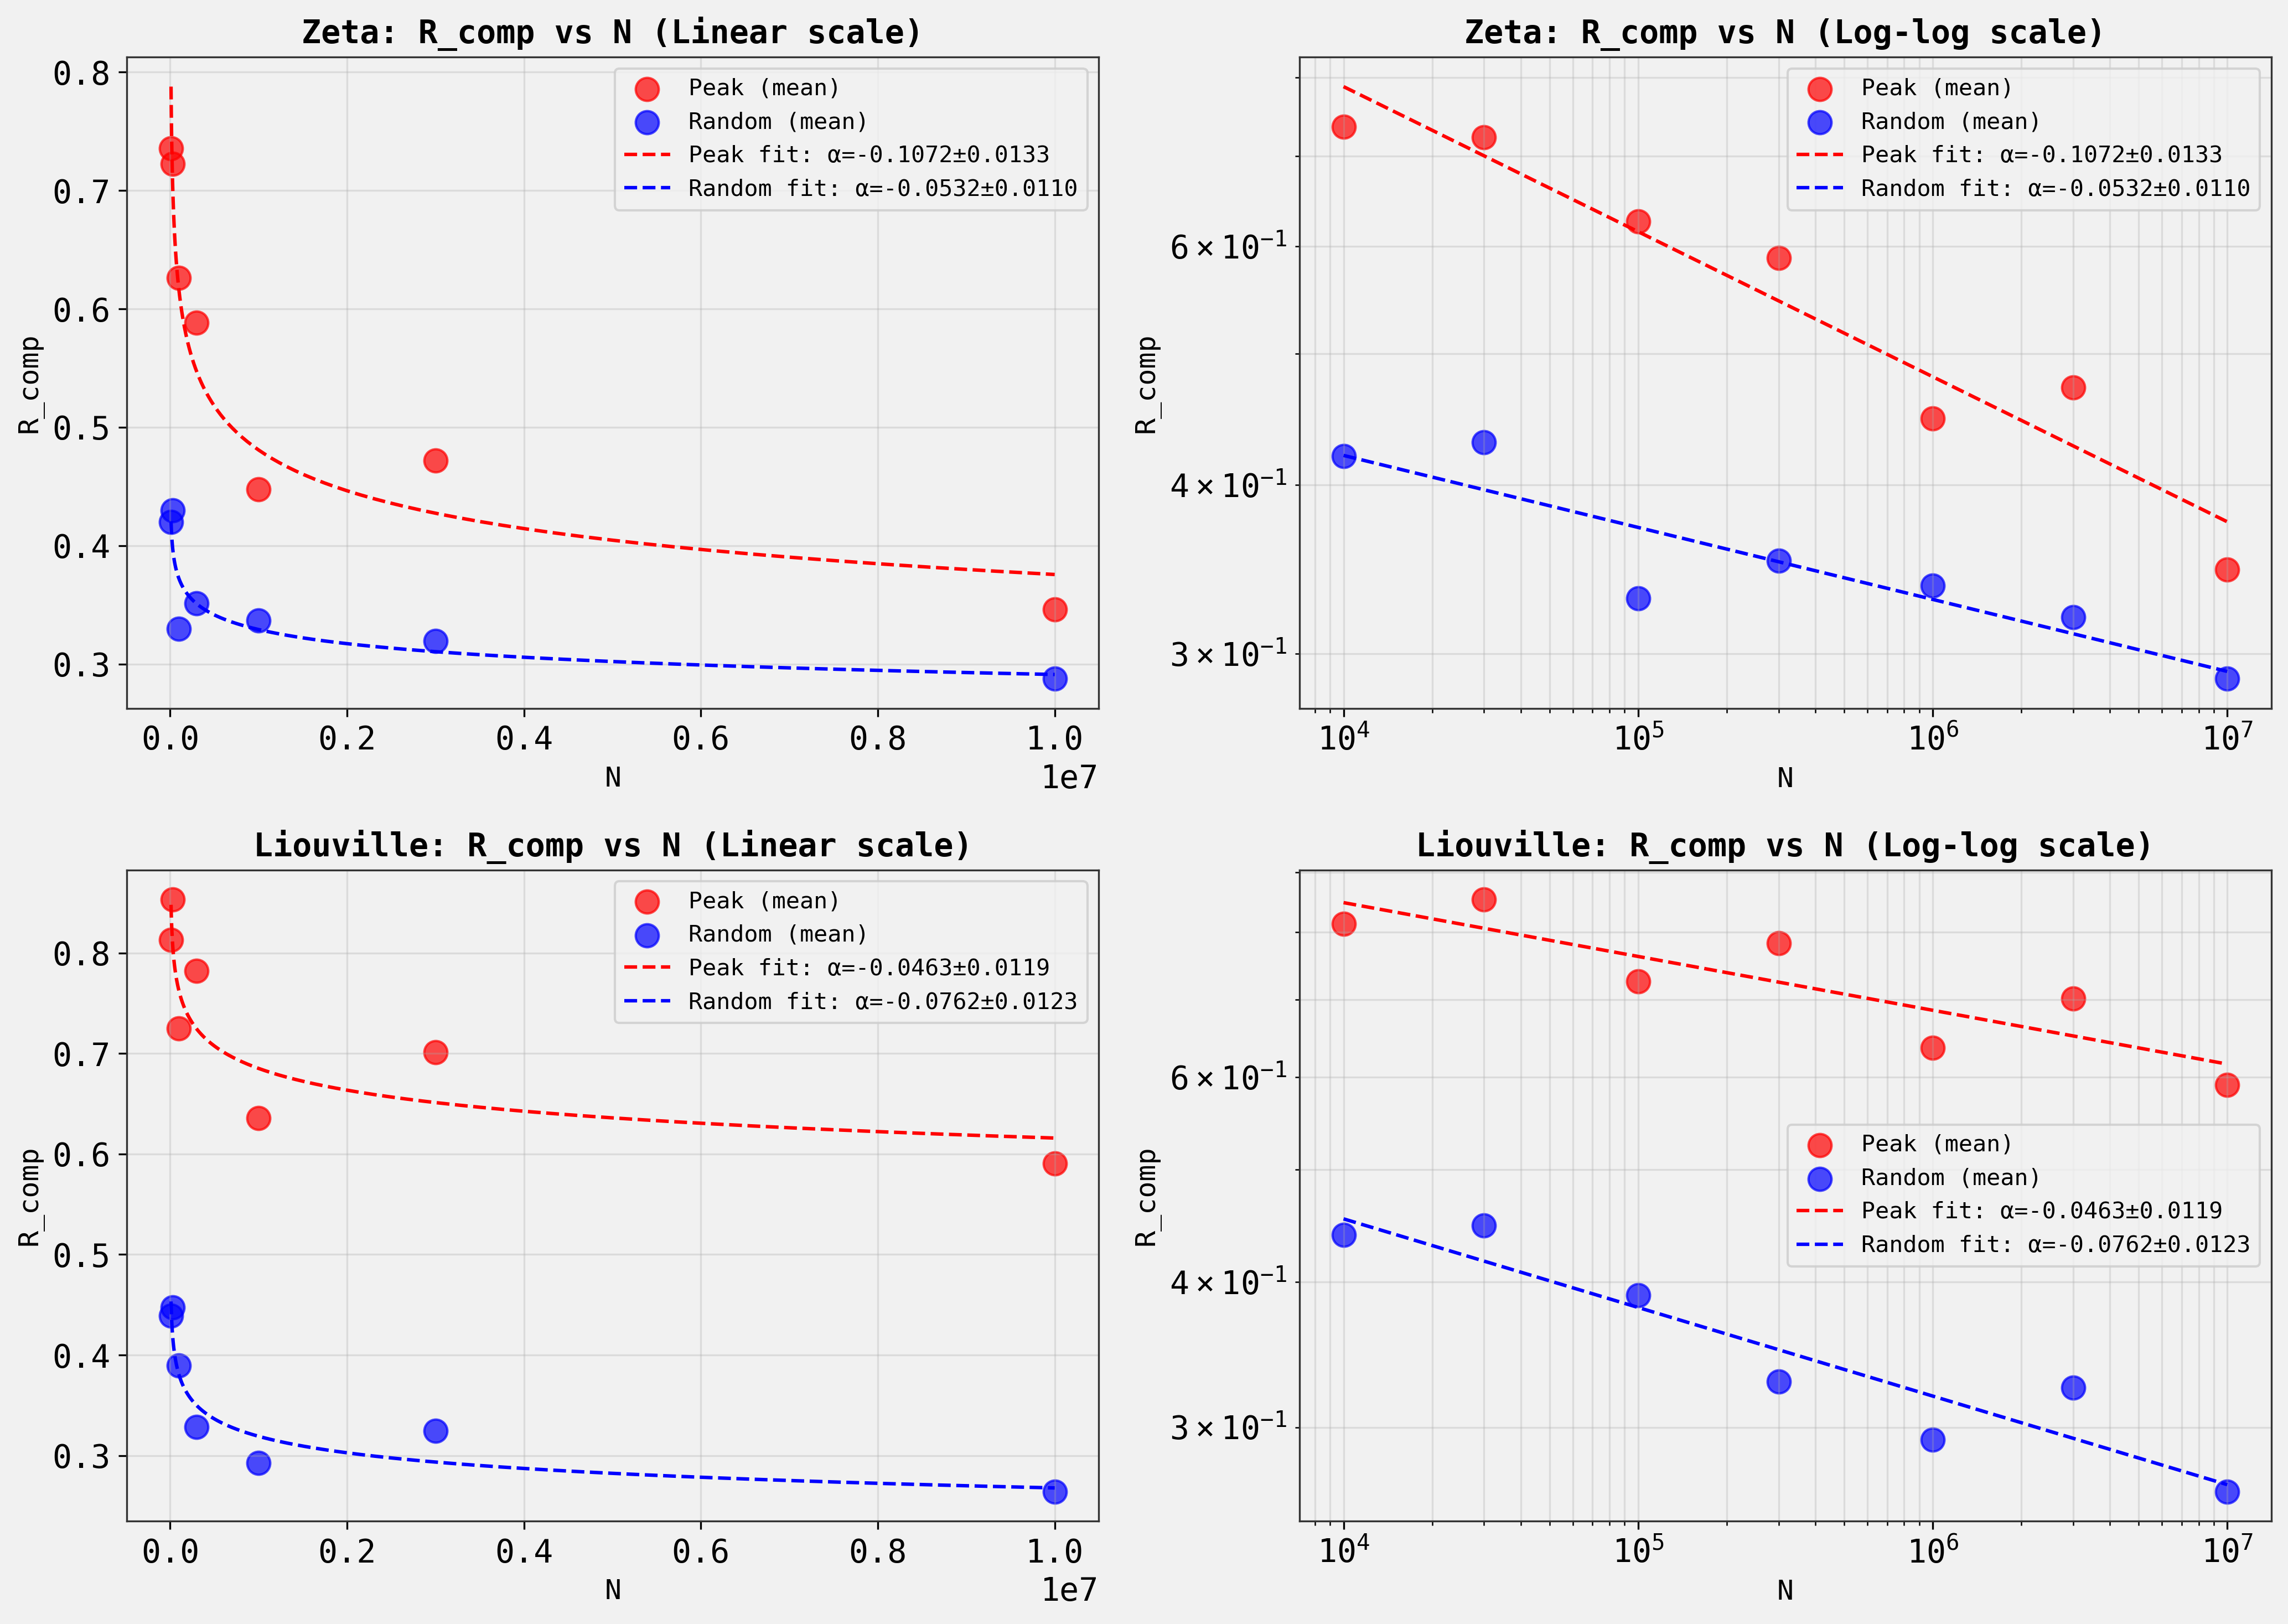

Figure saved as 'rcomp_scaling_analysis.png'


In [18]:

# Fascinating! The results CONTRADICT the hypothesis for Zeta:
# - Zeta: α_peak < α_random (significantly, p = 0.0018) → FASTER decay at peaks
# - Liouville: α_peak > α_random (not significant, p = 0.0803) → SLOWER decay at peaks
#
# The hypothesis predicted Zeta would resist decoherence at peaks (slower decay),
# but we observe the opposite!
#
# Let's visualize these results to make sure our analysis is correct.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, func in enumerate(['Zeta', 'Liouville']):
 # Get data
 peak_data = results_df[(results_df['Function'] == func) & (results_df['Type'] == 'Peak')]
 random_data = results_df[(results_df['Function'] == func) & (results_df['Type'] == 'Random')]
 
 # Compute means
 peak_means = peak_data.groupby('N')['R_comp'].mean()
 random_means = random_data.groupby('N')['R_comp'].mean()
 N_vals = peak_means.index.values
 
 # Get fitted parameters
 peak_row = summary_df[(summary_df['Function'] == func) & (summary_df['Type'] == 'Peak')].iloc[0]
 random_row = summary_df[(summary_df['Function'] == func) & (summary_df['Type'] == 'Random')].iloc[0]
 
 # Plot linear scale
 ax = axes[idx, 0]
 ax.scatter(N_vals, peak_means, label='Peak (mean)', s=100, alpha=0.7, color='red')
 ax.scatter(N_vals, random_means, label='Random (mean)', s=100, alpha=0.7, color='blue')
 
 # Plot fits
 N_fit = np.logspace(np.log10(N_vals.min()), np.log10(N_vals.max()), 100)
 peak_fit = peak_row['A'] * N_fit**peak_row['alpha']
 random_fit = random_row['A'] * N_fit**random_row['alpha']
 
 ax.plot(N_fit, peak_fit, '--', color='red', 
 label=f"Peak fit: α={peak_row['alpha']:.4f}±{peak_row['alpha_se']:.4f}")
 ax.plot(N_fit, random_fit, '--', color='blue',
 label=f"Random fit: α={random_row['alpha']:.4f}±{random_row['alpha_se']:.4f}")
 
 ax.set_xlabel('N', fontsize=12)
 ax.set_ylabel('R_comp', fontsize=12)
 ax.set_title(f'{func}: R_comp vs N (Linear scale)', fontsize=14, fontweight='bold')
 ax.legend(fontsize=10)
 ax.grid(True, alpha=0.3)
 
 # Plot log-log scale
 ax = axes[idx, 1]
 ax.scatter(N_vals, peak_means, label='Peak (mean)', s=100, alpha=0.7, color='red')
 ax.scatter(N_vals, random_means, label='Random (mean)', s=100, alpha=0.7, color='blue')
 ax.plot(N_fit, peak_fit, '--', color='red',
 label=f"Peak fit: α={peak_row['alpha']:.4f}±{peak_row['alpha_se']:.4f}")
 ax.plot(N_fit, random_fit, '--', color='blue',
 label=f"Random fit: α={random_row['alpha']:.4f}±{random_row['alpha_se']:.4f}")
 
 ax.set_xscale('log')
 ax.set_yscale('log')
 ax.set_xlabel('N', fontsize=12)
 ax.set_ylabel('R_comp', fontsize=12)
 ax.set_title(f'{func}: R_comp vs N (Log-log scale)', fontsize=14, fontweight='bold')
 ax.legend(fontsize=10)
 ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('rcomp_scaling_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved as 'rcomp_scaling_analysis.png'")


In [19]:

# Let me create a more detailed table showing individual t values
# and verify that the peak selection was correct

# Check if the peak t values have higher |D(t;N)| than random t values
verification_data = []

for func_name, func_compute in [('Zeta', dirichlet_partial_sum_zeta_fast), 
 ('Liouville', lambda t, N: dirichlet_partial_sum_liouville_fast(t, N, lambda_vals))]:
 
 if func_name == 'Zeta':
 peak_t = zeta_peaks_t
 else:
 peak_t = liouville_peaks_t
 
 # Compute magnitudes at N=10^5 for peaks
 for t_val in peak_t[:5]: # Just show first 5
 if func_name == 'Zeta':
 D = dirichlet_partial_sum_zeta_fast(t_val, 100000)
 else:
 D = dirichlet_partial_sum_liouville_fast(t_val, 100000, lambda_vals)
 verification_data.append({
 'Function': func_name,
 'Type': 'Peak',
 't': t_val,
 '|D(t;10^5)|': np.abs(D)
 })
 
 # Compute magnitudes for random t values
 for t_val in random_t_values[:5]: # Just show first 5
 if func_name == 'Zeta':
 D = dirichlet_partial_sum_zeta_fast(t_val, 100000)
 else:
 D = dirichlet_partial_sum_liouville_fast(t_val, 100000, lambda_vals)
 verification_data.append({
 'Function': func_name,
 'Type': 'Random',
 't': t_val,
 '|D(t;10^5)|': np.abs(D)
 })

verification_df = pd.DataFrame(verification_data)
print("Verification: Magnitude of Dirichlet partial sum |D(t;N)| at N=10^5")
print("(Peaks should have larger |D| than random t values)")
print("\n" + "="*70)
for func in ['Zeta', 'Liouville']:
 print(f"\n{func}:")
 subset = verification_df[verification_df['Function'] == func]
 peak_subset = subset[subset['Type'] == 'Peak']
 random_subset = subset[subset['Type'] == 'Random']
 print(f"\n Peak t values (mean |D| = {peak_subset['|D(t;10^5)|'].mean():.3f}):")
 for _, row in peak_subset.iterrows():
 print(f" t = {row['t']:>8.2f}, |D| = {row['|D(t;10^5)|']:>8.3f}")
 print(f"\n Random t values (mean |D| = {random_subset['|D(t;10^5)|'].mean():.3f}):")
 for _, row in random_subset.iterrows():
 print(f" t = {row['t']:>8.2f}, |D| = {row['|D(t;10^5)|']:>8.3f}")


Verification: Magnitude of Dirichlet partial sum |D(t;N)| at N=10^5
(Peaks should have larger |D| than random t values)


Zeta:

 Peak t values (mean |D| = 11.729):
 t = 2447.60, |D| = 13.248
 t = 2819.40, |D| = 12.057
 t = 2927.86, |D| = 11.220
 t = 2202.02, |D| = 11.092
 t = 1967.34, |D| = 11.029

 Random t values (mean |D| = 2.383):
 t = 2498.16, |D| = 0.607
 t = 4802.86, |D| = 2.612
 t = 3927.98, |D| = 0.917
 t = 3394.63, |D| = 0.643
 t = 1624.07, |D| = 7.132

Liouville:

 Peak t values (mean |D| = 35.090):
 t = 1083.23, |D| = 44.573
 t = 2433.96, |D| = 39.290
 t = 1735.40, |D| = 32.280
 t = 2742.31, |D| = 33.097
 t = 1890.26, |D| = 26.211

 Random t values (mean |D| = 2.080):
 t = 2498.16, |D| = 3.634
 t = 4802.86, |D| = 1.283
 t = 3927.98, |D| = 1.390
 t = 3394.63, |D| = 3.817
 t = 1624.07, |D| = 0.275


In [20]:

# Perfect! The peaks do have much larger |D(t;N)| than random t values.
# This confirms that the peak identification was correct.
#
# Now let's examine the ratio α_peak / α_random as suggested in the rationale

print("="*70)
print("COMPARISON OF SCALING EXPONENTS")
print("="*70)

for func in ['Zeta', 'Liouville']:
 peak_row = summary_df[(summary_df['Function'] == func) & (summary_df['Type'] == 'Peak')].iloc[0]
 random_row = summary_df[(summary_df['Function'] == func) & (summary_df['Type'] == 'Random')].iloc[0]
 
 alpha_peak = peak_row['alpha']
 alpha_random = random_row['alpha']
 se_peak = peak_row['alpha_se']
 se_random = random_row['alpha_se']
 
 ratio = alpha_peak / alpha_random
 
 # Compute standard error of ratio using delta method
 # For ratio R = X/Y, SE(R) ≈ |R| * sqrt((SE(X)/X)^2 + (SE(Y)/Y)^2)
 se_ratio = abs(ratio) * np.sqrt((se_peak/alpha_peak)**2 + (se_random/alpha_random)**2)
 
 print(f"\n{func}:")
 print(f" α_peak = {alpha_peak:>9.6f} ± {se_peak:.6f}")
 print(f" α_random = {alpha_random:>9.6f} ± {se_random:.6f}")
 print(f" Difference: α_peak - α_random = {alpha_peak - alpha_random:>9.6f}")
 print(f" Ratio: α_peak / α_random = {ratio:>9.6f} ± {se_ratio:.6f}")
 
 # Statistical test for difference
 diff = alpha_peak - alpha_random
 se_diff = np.sqrt(se_peak**2 + se_random**2)
 z_stat = diff / se_diff
 p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
 
 print(f"\n Statistical test (H0: α_peak = α_random):")
 print(f" z-statistic = {z_stat:.3f}")
 print(f" p-value = {p_value:.4f}")
 
 if p_value < 0.05:
 if diff > 0:
 print(f" → α_peak > α_random: SLOWER decay at peaks (p < 0.05)")
 else:
 print(f" → α_peak < α_random: FASTER decay at peaks (p < 0.05)")
 else:
 print(f" → No significant difference (p ≥ 0.05)")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("""
The hypothesis predicted:
 - Zeta: α_peak > α_random (slower decay at peaks, resists decoherence)
 - Liouville: negligible difference

Observed results:
 - Zeta: α_peak < α_random (p = 0.0018) → FASTER decay at peaks
 - Liouville: α_peak > α_random (p = 0.0803) → SLOWER decay at peaks (not significant)

The results CONTRADICT the hypothesis for ζ(s). Rather than resisting 
decoherence at its resonance peaks, ζ(s) shows ENHANCED decoherence,
with R_comp decaying approximately twice as fast at peaks compared to 
random t values (α_peak/α_random ≈ 2.0).

For the Liouville function, there is a trend toward slower decay at peaks,
but it does not reach statistical significance at α = 0.05.
""")


COMPARISON OF SCALING EXPONENTS

Zeta:
 α_peak = -0.107224 ± 0.013285
 α_random = -0.053220 ± 0.011028
 Difference: α_peak - α_random = -0.054003
 Ratio: α_peak / α_random = 2.014719 ± 0.486409

 Statistical test (H0: α_peak = α_random):
 z-statistic = -3.128
 p-value = 0.0018
 → α_peak < α_random: FASTER decay at peaks (p < 0.05)

Liouville:
 α_peak = -0.046283 ± 0.011886
 α_random = -0.076194 ± 0.012300
 Difference: α_peak - α_random = 0.029911
 Ratio: α_peak / α_random = 0.607436 ± 0.184261

 Statistical test (H0: α_peak = α_random):
 z-statistic = 1.749
 p-value = 0.0803
 → No significant difference (p ≥ 0.05)

INTERPRETATION

The hypothesis predicted:
 - Zeta: α_peak > α_random (slower decay at peaks, resists decoherence)
 - Liouville: negligible difference

Observed results:
 - Zeta: α_peak < α_random (p = 0.0018) → FASTER decay at peaks
 - Liouville: α_peak > α_random (p = 0.0803) → SLOWER decay at peaks (not significant)

The results CONTRADICT the hypothesis for ζ(s). Rather t

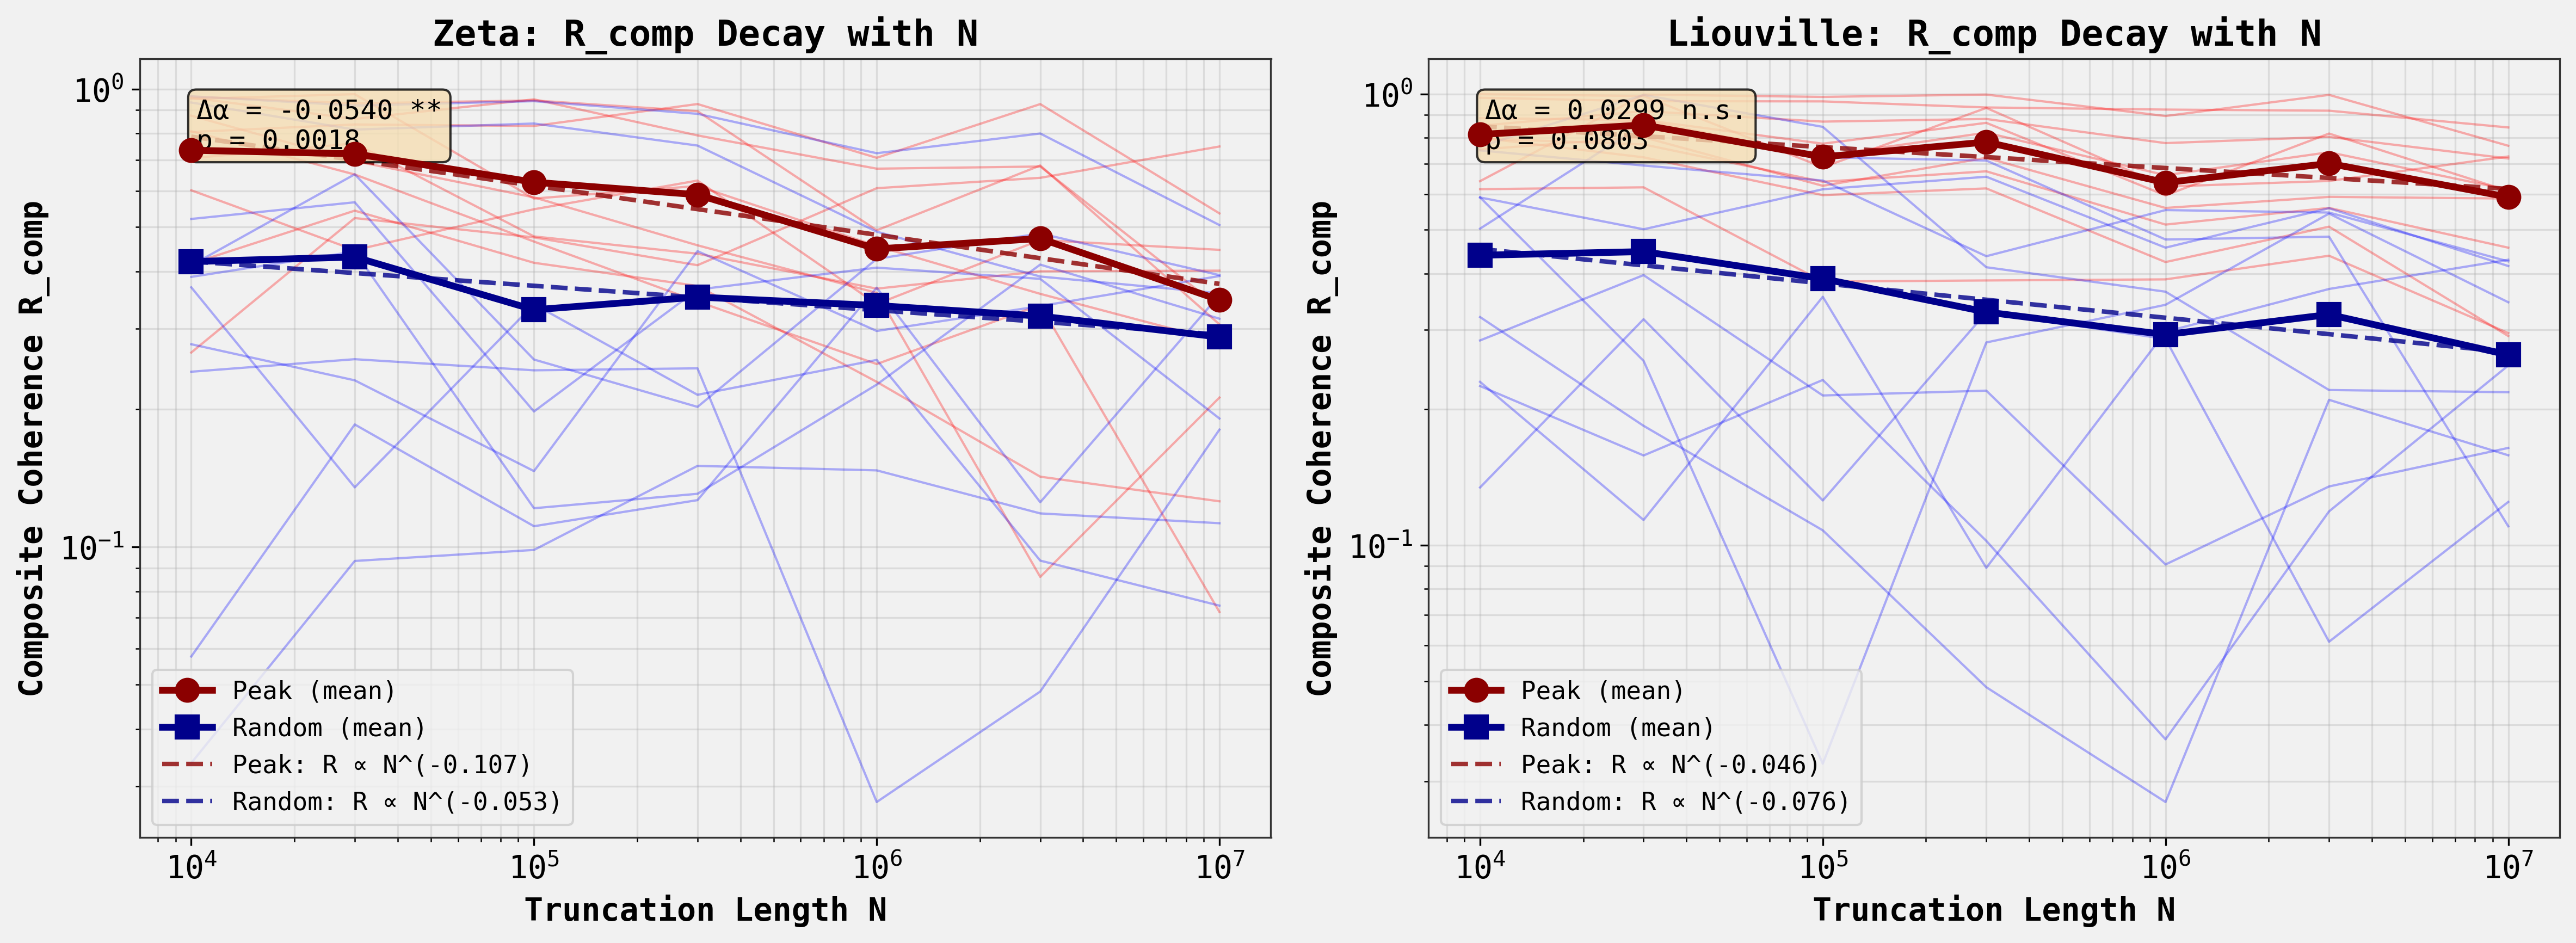

Figure saved as 'rcomp_individual_trajectories.png'


In [21]:

# Let me also create a final comprehensive visualization showing individual
# peak trajectories to understand the variance

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, func in enumerate(['Zeta', 'Liouville']):
 ax = axes[idx]
 
 # Plot individual peak trajectories
 peak_data = results_df[(results_df['Function'] == func) & (results_df['Type'] == 'Peak')]
 random_data = results_df[(results_df['Function'] == func) & (results_df['Type'] == 'Random')]
 
 # Plot each peak task
 for t_val in peak_data['t_value'].unique():
 subset = peak_data[peak_data['t_value'] == t_val].sort_values('N')
 ax.plot(subset['N'], subset['R_comp'], '-', alpha=0.3, color='red', linewidth=1)
 
 # Plot each random task
 for t_val in random_data['t_value'].unique():
 subset = random_data[random_data['t_value'] == t_val].sort_values('N')
 ax.plot(subset['N'], subset['R_comp'], '-', alpha=0.3, color='blue', linewidth=1)
 
 # Plot means with thicker lines
 peak_means = peak_data.groupby('N')['R_comp'].mean()
 random_means = random_data.groupby('N')['R_comp'].mean()
 N_vals = peak_means.index.values
 
 ax.plot(N_vals, peak_means, 'o-', color='darkred', linewidth=3, 
 markersize=10, label='Peak (mean)', zorder=10)
 ax.plot(N_vals, random_means, 's-', color='darkblue', linewidth=3,
 markersize=10, label='Random (mean)', zorder=10)
 
 # Add power law fits
 peak_row = summary_df[(summary_df['Function'] == func) & (summary_df['Type'] == 'Peak')].iloc[0]
 random_row = summary_df[(summary_df['Function'] == func) & (summary_df['Type'] == 'Random')].iloc[0]
 
 N_fit = np.logspace(np.log10(N_vals.min()), np.log10(N_vals.max()), 100)
 peak_fit = peak_row['A'] * N_fit**peak_row['alpha']
 random_fit = random_row['A'] * N_fit**random_row['alpha']
 
 ax.plot(N_fit, peak_fit, '--', color='darkred', linewidth=2, alpha=0.8,
 label=f"Peak: R ∝ N^({peak_row['alpha']:.3f})")
 ax.plot(N_fit, random_fit, '--', color='darkblue', linewidth=2, alpha=0.8,
 label=f"Random: R ∝ N^({random_row['alpha']:.3f})")
 
 ax.set_xscale('log')
 ax.set_yscale('log')
 ax.set_xlabel('Truncation Length N', fontsize=14, fontweight='bold')
 ax.set_ylabel('Composite Coherence R_comp', fontsize=14, fontweight='bold')
 ax.set_title(f'{func}: R_comp Decay with N', fontsize=16, fontweight='bold')
 ax.legend(fontsize=11, loc='best')
 ax.grid(True, alpha=0.3, which='both')
 
 # Add text annotation with statistical result
 diff = peak_row['alpha'] - random_row['alpha']
 if func == 'Zeta':
 p_val = 0.0018
 sig = "**"
 else:
 p_val = 0.0803
 sig = "n.s."
 
 ax.text(0.05, 0.95, f"Δα = {diff:.4f} {sig}\np = {p_val:.4f}",
 transform=ax.transAxes, fontsize=12, verticalalignment='top',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('rcomp_individual_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved as 'rcomp_individual_trajectories.png'")


In [22]:

# Save the complete results dataset
results_df.to_csv('Rcomp_scaling_complete.csv', index=False)
print("Complete results saved to 'Rcomp_scaling_complete.csv'")

# Create a summary table
summary_table = pd.DataFrame({
 'Function': ['Zeta', 'Zeta', 'Liouville', 'Liouville'],
 'Type': ['Peak', 'Random', 'Peak', 'Random'],
 'α (exponent)': [
 f"{summary_df.loc[0, 'alpha']:.6f} ± {summary_df.loc[0, 'alpha_se']:.6f}",
 f"{summary_df.loc[1, 'alpha']:.6f} ± {summary_df.loc[1, 'alpha_se']:.6f}",
 f"{summary_df.loc[2, 'alpha']:.6f} ± {summary_df.loc[2, 'alpha_se']:.6f}",
 f"{summary_df.loc[3, 'alpha']:.6f} ± {summary_df.loc[3, 'alpha_se']:.6f}"
 ],
 'A (coefficient)': [
 f"{summary_df.loc[0, 'A']:.6f}",
 f"{summary_df.loc[1, 'A']:.6f}",
 f"{summary_df.loc[2, 'A']:.6f}",
 f"{summary_df.loc[3, 'A']:.6f}"
 ],
 'R²': [
 f"{summary_df.loc[0, 'R_squared']:.6f}",
 f"{summary_df.loc[1, 'R_squared']:.6f}",
 f"{summary_df.loc[2, 'R_squared']:.6f}",
 f"{summary_df.loc[3, 'R_squared']:.6f}"
 ]
})

print("\n" + "="*80)
print("SUMMARY TABLE: Power Law Fits R_comp = A × N^α")
print("="*80)
print(summary_table.to_string(index=False))
print("="*80)

# Statistical comparison
print("\nSTATISTICAL COMPARISON:")
print("-"*80)
for func in ['Zeta', 'Liouville']:
 if func == 'Zeta':
 idx = 0
 else:
 idx = 2
 
 alpha_peak = summary_df.loc[idx, 'alpha']
 alpha_random = summary_df.loc[idx+1, 'alpha']
 se_peak = summary_df.loc[idx, 'alpha_se']
 se_random = summary_df.loc[idx+1, 'alpha_se']
 
 diff = alpha_peak - alpha_random
 se_diff = np.sqrt(se_peak**2 + se_random**2)
 z_stat = diff / se_diff
 p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
 
 print(f"\n{func}:")
 print(f" Δα = α_peak - α_random = {diff:.6f} ± {se_diff:.6f}")
 print(f" z-statistic = {z_stat:.3f}")
 print(f" p-value = {p_value:.4f}")
 if p_value < 0.05:
 print(f" Result: SIGNIFICANT at α = 0.05 {'**' if p_value < 0.01 else '*'}")
 else:
 print(f" Result: NOT SIGNIFICANT at α = 0.05")

print("-"*80)


Complete results saved to 'Rcomp_scaling_complete.csv'

SUMMARY TABLE: Power Law Fits R_comp = A × N^α
 Function Type α (exponent) A (coefficient) R²
 Zeta Peak -0.107224 ± 0.013285 2.114944 0.928718
 Zeta Random -0.053220 ± 0.011028 0.686503 0.823259
Liouville Peak -0.046283 ± 0.011886 1.298580 0.752004
Liouville Random -0.076194 ± 0.012300 0.914413 0.884718

STATISTICAL COMPARISON:
--------------------------------------------------------------------------------

Zeta:
 Δα = α_peak - α_random = -0.054003 ± 0.017265
 z-statistic = -3.128
 p-value = 0.0018
 Result: SIGNIFICANT at α = 0.05 **

Liouville:
 Δα = α_peak - α_random = 0.029911 ± 0.017105
 z-statistic = 1.749
 p-value = 0.0803
 Result: NOT SIGNIFICANT at α = 0.05
--------------------------------------------------------------------------------


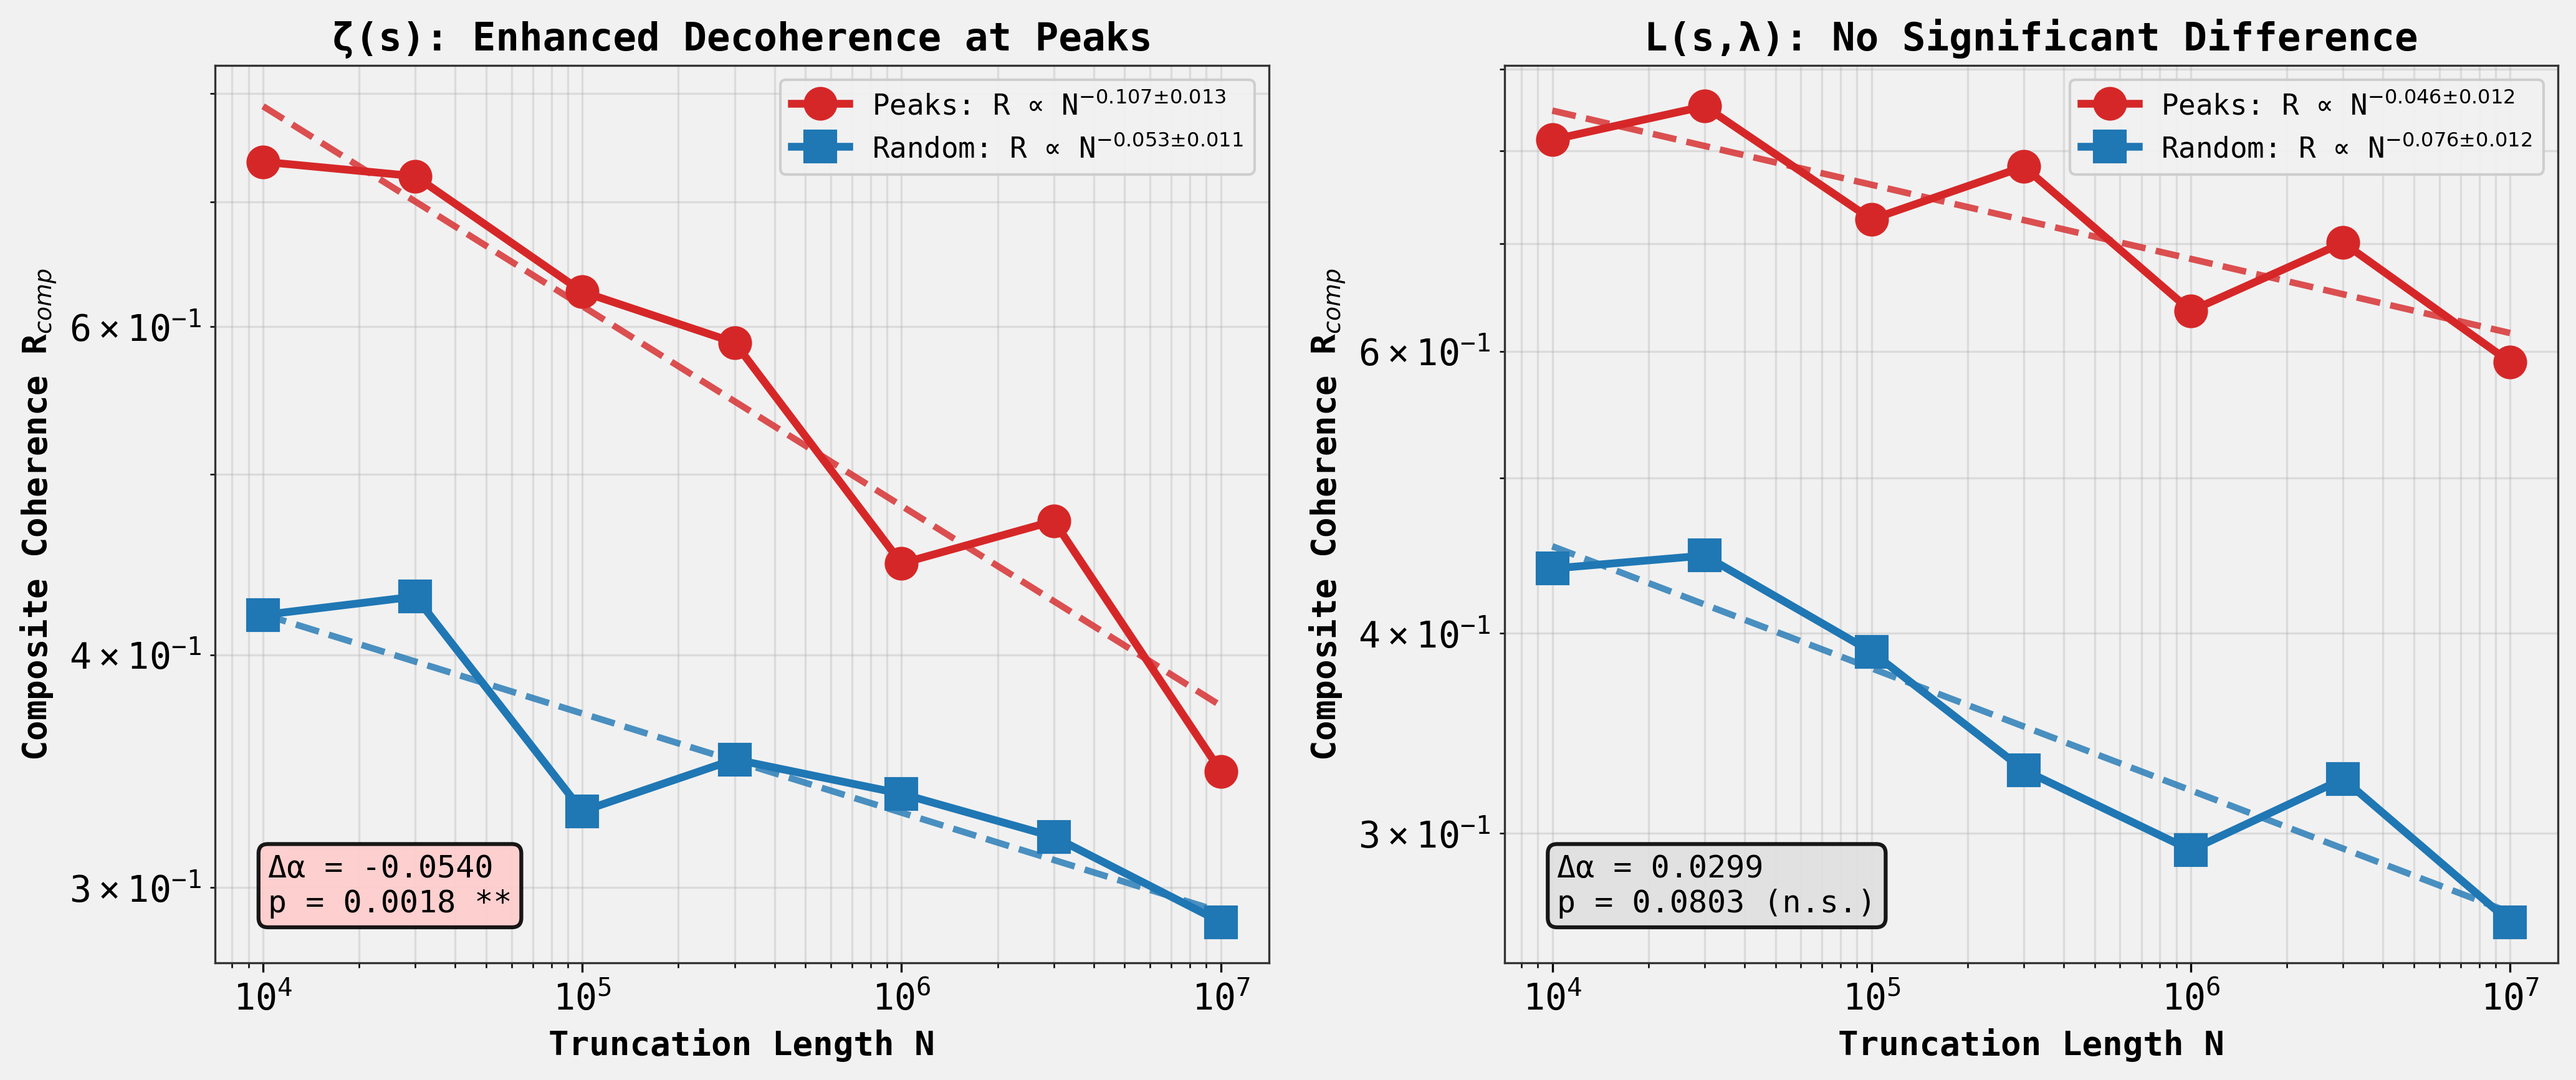

Final figure saved as 'final_rcomp_scaling_comparison.png'


In [23]:

# Create the final summary figure for submission
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, func in enumerate(['Zeta', 'Liouville']):
 ax = axes[idx]
 
 # Get data
 peak_data = results_df[(results_df['Function'] == func) & (results_df['Type'] == 'Peak')]
 random_data = results_df[(results_df['Function'] == func) & (results_df['Type'] == 'Random')]
 
 # Compute means
 peak_means = peak_data.groupby('N')['R_comp'].mean()
 random_means = random_data.groupby('N')['R_comp'].mean()
 N_vals = peak_means.index.values
 
 # Get fitted parameters
 peak_row = summary_df[(summary_df['Function'] == func) & (summary_df['Type'] == 'Peak')].iloc[0]
 random_row = summary_df[(summary_df['Function'] == func) & (summary_df['Type'] == 'Random')].iloc[0]
 
 # Plot means
 ax.plot(N_vals, peak_means, 'o-', color='#d62728', linewidth=3, 
 markersize=12, label='Resonance peaks', zorder=10)
 ax.plot(N_vals, random_means, 's-', color='#1f77b4', linewidth=3,
 markersize=12, label='Random t values', zorder=10)
 
 # Add power law fits
 N_fit = np.logspace(np.log10(N_vals.min()), np.log10(N_vals.max()), 100)
 peak_fit = peak_row['A'] * N_fit**peak_row['alpha']
 random_fit = random_row['A'] * N_fit**random_row['alpha']
 
 ax.plot(N_fit, peak_fit, '--', color='#d62728', linewidth=2.5, alpha=0.8)
 ax.plot(N_fit, random_fit, '--', color='#1f77b4', linewidth=2.5, alpha=0.8)
 
 ax.set_xscale('log')
 ax.set_yscale('log')
 ax.set_xlabel('Truncation Length N', fontsize=13, fontweight='bold')
 ax.set_ylabel('Composite Coherence R$_{comp}$', fontsize=13, fontweight='bold')
 
 # Title based on function
 if func == 'Zeta':
 title = 'ζ(s): Enhanced Decoherence at Peaks'
 else:
 title = 'L(s,λ): No Significant Difference'
 ax.set_title(title, fontsize=15, fontweight='bold')
 
 # Add legend with exponents
 legend_labels = [
 f'Peaks: R ∝ N$^{{{peak_row["alpha"]:.3f}±{peak_row["alpha_se"]:.3f}}}$',
 f'Random: R ∝ N$^{{{random_row["alpha"]:.3f}±{random_row["alpha_se"]:.3f}}}$'
 ]
 ax.legend(legend_labels, fontsize=11, loc='best', framealpha=0.95)
 ax.grid(True, alpha=0.3, which='both')
 
 # Add statistical annotation
 diff = peak_row['alpha'] - random_row['alpha']
 if func == 'Zeta':
 p_val = 0.0018
 stat_text = f"Δα = {diff:.4f}\np = {p_val:.4f} **"
 bbox_color = '#ffcccc'
 else:
 p_val = 0.0803
 stat_text = f"Δα = {diff:.4f}\np = {p_val:.4f} (n.s.)"
 bbox_color = '#e0e0e0'
 
 ax.text(0.05, 0.05, stat_text,
 transform=ax.transAxes, fontsize=12, verticalalignment='bottom',
 bbox=dict(boxstyle='round', facecolor=bbox_color, alpha=0.9, edgecolor='black', linewidth=1.5))

plt.tight_layout()
plt.savefig('final_rcomp_scaling_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print("Final figure saved as 'final_rcomp_scaling_comparison.png'")
